# 🤟 Sign Language Recognition — BTech PVR Lab
## YOLO11s | 50+ Classes | A–Z · 0–9 · Word Gestures

---
### 📋 Dataset Strategy (Verified — March 2026)

**No single public dataset covers all 50+ classes in ready YOLO format.**  
This notebook uses a **two-source merge** strategy — a standard academic practice:

| Source | Classes | Format | Link |
|--------|---------|--------|------|
| Kaggle: `prathumarikeri/american-sign-language-09az` | 36 (A–Z + 0–9) | Image folders | Active ✅ |
| Roboflow: `sign-language-detection-yolo-v10` | 15–20 Word gestures | YOLOv8 TXT | Active ✅ |

**Merged total: 51–56 classes** — satisfies BTech 4-credit lab requirement.

### ⚠️ Pre-flight Checklist
1. `Runtime → Change runtime type → T4 GPU`
2. Prepare your `kaggle.json` API key (instructions in Cell 2)
3. Prepare your free Roboflow API key from [app.roboflow.com](https://app.roboflow.com)


---
## 🔑 CELL 1 — API Key Setup Instructions

**Kaggle API Key:**
1. Go to [kaggle.com/account](https://www.kaggle.com/account)
2. Scroll to "API" section → click **Create New Token**
3. A `kaggle.json` file downloads — upload it when prompted in Cell 2

**Roboflow API Key:**
1. Go to [app.roboflow.com](https://app.roboflow.com) → sign up free
2. Top-right avatar → **Settings** → **API Keys** → copy your Private Key
3. Paste it in the `ROBOFLOW_API_KEY` variable in Cell 3

In [ ]:
# ============================================================
# CELL 2 — Environment Setup & Kaggle Auth (Token-based)
# ============================================================
import os, json, shutil
!pip install ultralytics roboflow kaggle --quiet

# ── Paste your Kaggle credentials here ──────────────────────
KAGGLE_USERNAME = "aantriksh"       # ← your Kaggle username
KAGGLE_KEY      = "KGAT_3ae092bf5d4513693c4b77b26b706799"  # ← your token
# ────────────────────────────────────────────────────────────

# Write kaggle.json directly — no file upload required
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Verify it worked
!kaggle datasets list --search "american sign language" -p 3
print("✅ Kaggle API key configured!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 71.1 MB/s eta 0:00:00
ref                                                             title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
shayanriyaz/gesture-recognition                                 Gesture Recognition                                     1574842  202

In [ ]:
# ============================================================
# CELL 3 — Roboflow API Key (paste yours here)
# ============================================================
ROBOFLOW_API_KEY = "95v2If914tAMiAI7nG2w"  # <-- Paste your key here

# Verify GPU
import torch
print(f"🖥️  GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   Device: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU")

🖥️  GPU available: True
   Device: Tesla T4


In [ ]:
# ============================================================
# CELL 4 — Download Source 1: Kaggle ASL (A–Z + 0–9, 36 classes)
# Dataset: prathumarikeri/american-sign-language-09az
# Description: ~78,000 images, 36 classes in folder structure
# ============================================================
BASE_DIR = '/content/sign_language_dataset'
KAGGLE_DIR = f'{BASE_DIR}/kaggle_asl'
os.makedirs(KAGGLE_DIR, exist_ok=True)

print("⬇️  Downloading Kaggle ASL dataset (A–Z + 0–9)...")
!kaggle datasets download -d prathumarikeri/american-sign-language-09az -p {KAGGLE_DIR} --unzip --quiet
print("✅ Kaggle ASL dataset downloaded!")

# Verify download — list top-level folders
import os
contents = os.listdir(KAGGLE_DIR)
print(f"📁 Downloaded folders/files: {sorted(contents)[:10]}... (showing first 10)")

⬇️  Downloading Kaggle ASL dataset (A–Z + 0–9)...
Dataset URL: https://www.kaggle.com/datasets/prathumarikeri/american-sign-language-09az
License(s): CC-BY-SA-4.0
✅ Kaggle ASL dataset downloaded!
📁 Downloaded folders/files: ['American']... (showing first 10)


In [ ]:
# ============================================================
# CELL 5 — Download Source 2: Roboflow Word Gestures (15-20 classes)
# Dataset: sign-language-detection-yolo-v10
# Words: Hello, Help, Thank You, Yes, No, I Love You, Water,
#        Food, More, Please, Stop, Come, Go, Good, Bad, Emergency
# ============================================================
from roboflow import Roboflow

ROBOFLOW_DIR = f'{BASE_DIR}/roboflow_words'
os.makedirs(ROBOFLOW_DIR, exist_ok=True)
os.chdir(ROBOFLOW_DIR)

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Download sign language WORDS dataset in YOLOv11 format
# This dataset contains common word gestures annotated in YOLO format
print("⬇️  Downloading Roboflow sign language words dataset...")
project = rf.workspace("sign-language-translation-alilj").project("sign-language-detection-yolo-v10")
dataset = project.version(1).download("yolov8")  # yolov8 format = compatible with yolo11

print(f"✅ Roboflow words dataset downloaded to: {ROBOFLOW_DIR}")
os.chdir('/content')

⬇️  Downloading Roboflow sign language words dataset...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sign-language-detection-YOLO-V10-1 in yolov8:: 100%|██████████| 2384/2384 [00:00<00:00, 6505.68it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Roboflow words dataset downloaded to: /content/sign_language_dataset/roboflow_words


In [ ]:
# ============================================================
# CELL 6 — PREPROCESSING: Convert Kaggle folders → YOLO format
#
# Kaggle dataset is in classification format:
#   kaggle_asl/
#     A/ [images...]
#     B/ [images...]
#     ... etc
# We convert this to YOLO detection format with bounding boxes
# ============================================================
import glob
import random
import shutil
from PIL import Image

MERGED_DIR = f'{BASE_DIR}/merged_dataset'
for split in ['train', 'val', 'test']:
    os.makedirs(f'{MERGED_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{MERGED_DIR}/{split}/labels', exist_ok=True)

# ---- Step 1: Identify Kaggle class folders ----
# The dataset may have sub-folders like 'asl_dataset/A', 'asl_dataset/B', etc.
# Auto-detect the root folder
def find_class_root(base):
    """Find the directory that contains class sub-folders."""
    for root, dirs, files in os.walk(base):
        # Look for directory with 36 sub-dirs (A-Z + 0-9)
        subdirs = [d for d in dirs if len(d) == 1]
        if len(subdirs) >= 30:
            return root
    return base

kaggle_root = find_class_root(KAGGLE_DIR)
print(f"📁 Found Kaggle class root: {kaggle_root}")

# Collect class names: digits 0-9 then letters A-Z
kaggle_classes = sorted([d for d in os.listdir(kaggle_root)
                         if os.path.isdir(os.path.join(kaggle_root, d))])
print(f"📋 Kaggle classes ({len(kaggle_classes)}): {kaggle_classes}")

📁 Found Kaggle class root: /content/sign_language_dataset/kaggle_asl/American
📋 Kaggle classes (36): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
# ============================================================
# CELL 7 — Convert Kaggle → YOLO Labels (full-image bounding box)
# For classification-style datasets, the whole hand IS the object,
# so we use a full-frame bbox (0.5, 0.5, 1.0, 1.0) — standard practice
# for ASL classification-to-detection conversion.
# ============================================================
TRAIN_RATIO, VAL_RATIO = 0.80, 0.10  # 80/10/10 split
MAX_IMAGES_PER_CLASS = 500  # Limit to keep Colab manageable; increase if you have time

print(f"🔄 Converting Kaggle dataset → YOLO format...")
print(f"   Max images per class: {MAX_IMAGES_PER_CLASS}")

converted_count = 0
for class_idx, class_name in enumerate(kaggle_classes):
    class_dir = os.path.join(kaggle_root, class_name)
    images = glob.glob(f'{class_dir}/*.jpg') + \
             glob.glob(f'{class_dir}/*.png') + \
             glob.glob(f'{class_dir}/*.jpeg')
    random.shuffle(images)
    images = images[:MAX_IMAGES_PER_CLASS]  # cap per class

    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = (['train'] * n_train +
              ['val']   * n_val +
              ['test']  * (n - n_train - n_val))

    for img_path, split in zip(images, splits):
        fname = os.path.splitext(os.path.basename(img_path))[0]
        safe_name = f"kaggle_{class_name}_{fname}"

        # Copy image
        dst_img = f'{MERGED_DIR}/{split}/images/{safe_name}.jpg'
        shutil.copy(img_path, dst_img)

        # Write YOLO label: class_idx cx cy w h (full-frame box)
        dst_lbl = f'{MERGED_DIR}/{split}/labels/{safe_name}.txt'
        with open(dst_lbl, 'w') as f:
            f.write(f"{class_idx} 0.5 0.5 1.0 1.0\n")

        converted_count += 1

print(f"✅ Converted {converted_count} images from {len(kaggle_classes)} Kaggle classes.")

🔄 Converting Kaggle dataset → YOLO format...
   Max images per class: 500
✅ Converted 18000 images from 36 Kaggle classes.


In [ ]:
# ============================================================
# CELL 8 — Parse Roboflow Word Classes & Merge into Dataset
# ============================================================
import yaml

# Find Roboflow data.yaml
rf_yaml_path = None
for root, dirs, files in os.walk(ROBOFLOW_DIR):
    for f in files:
        if f == 'data.yaml':
            rf_yaml_path = os.path.join(root, f)
            break

if rf_yaml_path is None:
    raise FileNotFoundError("❌ Could not find Roboflow data.yaml. Check download.")

with open(rf_yaml_path, 'r') as f:
    rf_data = yaml.safe_load(f)

rf_classes = rf_data.get('names', [])
print(f"📋 Roboflow word classes ({len(rf_classes)}): {rf_classes}")

# Build MERGED class list: Kaggle classes first, then Roboflow words
# (Kaggle = 0..35, Roboflow words = 36..N)
KAGGLE_NC = len(kaggle_classes)          # e.g. 36
RF_NC = len(rf_classes)                  # e.g. 15-20
ALL_CLASSES = kaggle_classes + rf_classes
TOTAL_CLASSES = len(ALL_CLASSES)
print(f"\n🎯 TOTAL MERGED CLASSES: {TOTAL_CLASSES}")
print(f"   Kaggle (A-Z + 0-9): {KAGGLE_NC}")
print(f"   Roboflow (Words):    {RF_NC}")
print(f"   Full class list: {ALL_CLASSES}")

📋 Roboflow word classes (41): ['Again', 'Bad', 'Bathroom', 'Busy', 'Cat', 'Done', 'Eat', 'Father', 'Fine', 'Go To', 'Good', 'Help', 'Helpd', 'I Love You', 'Like', 'More', 'Mother', 'Need', 'No', 'No Sign Detected', 'Please', 'Right', 'Sad', 'So So', 'Thanks', 'Want', 'Wrong', 'Yes', 'car', 'cat', 'chicken breast', 'chicken noodle soup', 'd', 'dog', 'french onion soup', 'hello', 'marinara sauce', 'meatballs', 'person', 'tomato soup', 'tv']

🎯 TOTAL MERGED CLASSES: 77
   Kaggle (A-Z + 0-9): 36
   Roboflow (Words):    41
   Full class list: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'Again', 'Bad', 'Bathroom', 'Busy', 'Cat', 'Done', 'Eat', 'Father', 'Fine', 'Go To', 'Good', 'Help', 'Helpd', 'I Love You', 'Like', 'More', 'Mother', 'Need', 'No', 'No Sign Detected', 'Please', 'Right', 'Sad', 'So So', 'Thanks', 'Want', 'Wrong', 'Yes', 'car', 'cat', 'chicken

In [ ]:
# ============================================================
# CELL 9 — Merge Roboflow Images + Re-indexed Labels into Dataset
# Roboflow labels use class IDs 0..RF_NC-1
# We re-index them to KAGGLE_NC..TOTAL_CLASSES-1
# ============================================================
def copy_and_reindex(src_images_dir, src_labels_dir, split, offset):
    """Copy Roboflow images & relabel class IDs with an offset."""
    if not os.path.isdir(src_images_dir):
        print(f"   ⚠️  {src_images_dir} not found, skipping.")
        return 0

    img_files = glob.glob(f'{src_images_dir}/*.jpg') + \
                glob.glob(f'{src_images_dir}/*.png') + \
                glob.glob(f'{src_images_dir}/*.jpeg')

    count = 0
    for img_path in img_files:
        fname = os.path.splitext(os.path.basename(img_path))[0]
        safe_name = f"rf_{split}_{fname}"

        # Copy image
        shutil.copy(img_path, f'{MERGED_DIR}/{split}/images/{safe_name}.jpg')

        # Re-index label
        src_lbl = os.path.join(src_labels_dir, fname + '.txt')
        dst_lbl = f'{MERGED_DIR}/{split}/labels/{safe_name}.txt'
        if os.path.exists(src_lbl):
            with open(src_lbl, 'r') as fin, open(dst_lbl, 'w') as fout:
                for line in fin:
                    parts = line.strip().split()
                    if parts:
                        new_cls = int(parts[0]) + offset
                        fout.write(f"{new_cls} {' '.join(parts[1:])}\n")
            count += 1
        else:
            # No label file — skip (background image)
            os.remove(f'{MERGED_DIR}/{split}/images/{safe_name}.jpg')
    return count

# Find Roboflow split directories
rf_root = os.path.dirname(rf_yaml_path)
rf_split_map = {'train': 'train', 'val': 'valid', 'test': 'test'}

for split, rf_split in rf_split_map.items():
    img_dir = os.path.join(rf_root, rf_split, 'images')
    lbl_dir = os.path.join(rf_root, rf_split, 'labels')
    n = copy_and_reindex(img_dir, lbl_dir, split, offset=KAGGLE_NC)
    print(f"✅ Merged Roboflow {split}: {n} images")

# Final counts
for split in ['train', 'val', 'test']:
    n_imgs = len(glob.glob(f'{MERGED_DIR}/{split}/images/*'))
    n_lbls = len(glob.glob(f'{MERGED_DIR}/{split}/labels/*'))
    print(f"   {split}: {n_imgs} images | {n_lbls} labels")

✅ Merged Roboflow train: 837 images
✅ Merged Roboflow val: 232 images
✅ Merged Roboflow test: 117 images
   train: 15237 images | 15237 labels
   val: 2032 images | 2032 labels
   test: 1917 images | 1917 labels


In [ ]:
# ============================================================
# CELL 10 — Generate data.yaml with ABSOLUTE Colab Paths
# This is the most common source of YOLO training errors!
# ============================================================
import yaml

DATA_YAML_PATH = f'{MERGED_DIR}/data.yaml'

data_yaml = {
    'path':  MERGED_DIR,
    'train': f'{MERGED_DIR}/train/images',
    'val':   f'{MERGED_DIR}/val/images',
    'test':  f'{MERGED_DIR}/test/images',
    'nc':    TOTAL_CLASSES,
    'names': ALL_CLASSES
}

with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

# Pretty print for verification
print("✅ data.yaml generated!")
print("=" * 50)
with open(DATA_YAML_PATH, 'r') as f:
    print(f.read())
print("=" * 50)

✅ data.yaml generated!
names:
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- '8'
- '9'
- a
- b
- c
- d
- e
- f
- g
- h
- i
- j
- k
- l
- m
- n
- o
- p
- q
- r
- s
- t
- u
- v
- w
- x
- y
- z
- Again
- Bad
- Bathroom
- Busy
- Cat
- Done
- Eat
- Father
- Fine
- Go To
- Good
- Help
- Helpd
- I Love You
- Like
- More
- Mother
- Need
- 'No'
- No Sign Detected
- Please
- Right
- Sad
- So So
- Thanks
- Want
- Wrong
- 'Yes'
- car
- cat
- chicken breast
- chicken noodle soup
- d
- dog
- french onion soup
- hello
- marinara sauce
- meatballs
- person
- tomato soup
- tv
nc: 77
path: /content/sign_language_dataset/merged_dataset
test: /content/sign_language_dataset/merged_dataset/test/images
train: /content/sign_language_dataset/merged_dataset/train/images
val: /content/sign_language_dataset/merged_dataset/val/images



In [ ]:
# ============================================================
# CELL 11 — Dataset Verification (Label vs Class Sanity Check)
# Ensures all label IDs are within [0, TOTAL_CLASSES-1]
# ============================================================
print("🔍 Running dataset integrity check...")
errors = []
label_class_counts = {i: 0 for i in range(TOTAL_CLASSES)}

for split in ['train', 'val', 'test']:
    lbl_files = glob.glob(f'{MERGED_DIR}/{split}/labels/*.txt')
    for lbl_path in lbl_files:
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                if cls_id < 0 or cls_id >= TOTAL_CLASSES:
                    errors.append(f"{lbl_path}: invalid class {cls_id}")
                else:
                    label_class_counts[cls_id] += 1

if errors:
    print(f"❌ Found {len(errors)} label errors:")
    for e in errors[:5]: print(f"   {e}")
else:
    print(f"✅ All labels valid! No out-of-range class IDs.")

print("\n📊 Annotation counts per class:")
for idx, cls_name in enumerate(ALL_CLASSES):
    bar = '█' * min(label_class_counts[idx] // 50, 30)
    print(f"  [{idx:2d}] {cls_name:<15} {label_class_counts[idx]:6d}  {bar}")

🔍 Running dataset integrity check...
✅ All labels valid! No out-of-range class IDs.

📊 Annotation counts per class:
  [ 0] 0                  500  ██████████
  [ 1] 1                  500  ██████████
  [ 2] 2                  500  ██████████
  [ 3] 3                  500  ██████████
  [ 4] 4                  500  ██████████
  [ 5] 5                  500  ██████████
  [ 6] 6                  500  ██████████
  [ 7] 7                  500  ██████████
  [ 8] 8                  500  ██████████
  [ 9] 9                  500  ██████████
  [10] a                  500  ██████████
  [11] b                  500  ██████████
  [12] c                  500  ██████████
  [13] d                  500  ██████████
  [14] e                  500  ██████████
  [15] f                  500  ██████████
  [16] g                  500  ██████████
  [17] h                  500  ██████████
  [18] i                  500  ██████████
  [19] j                  500  ██████████
  [20] k                  500  ██████████
  

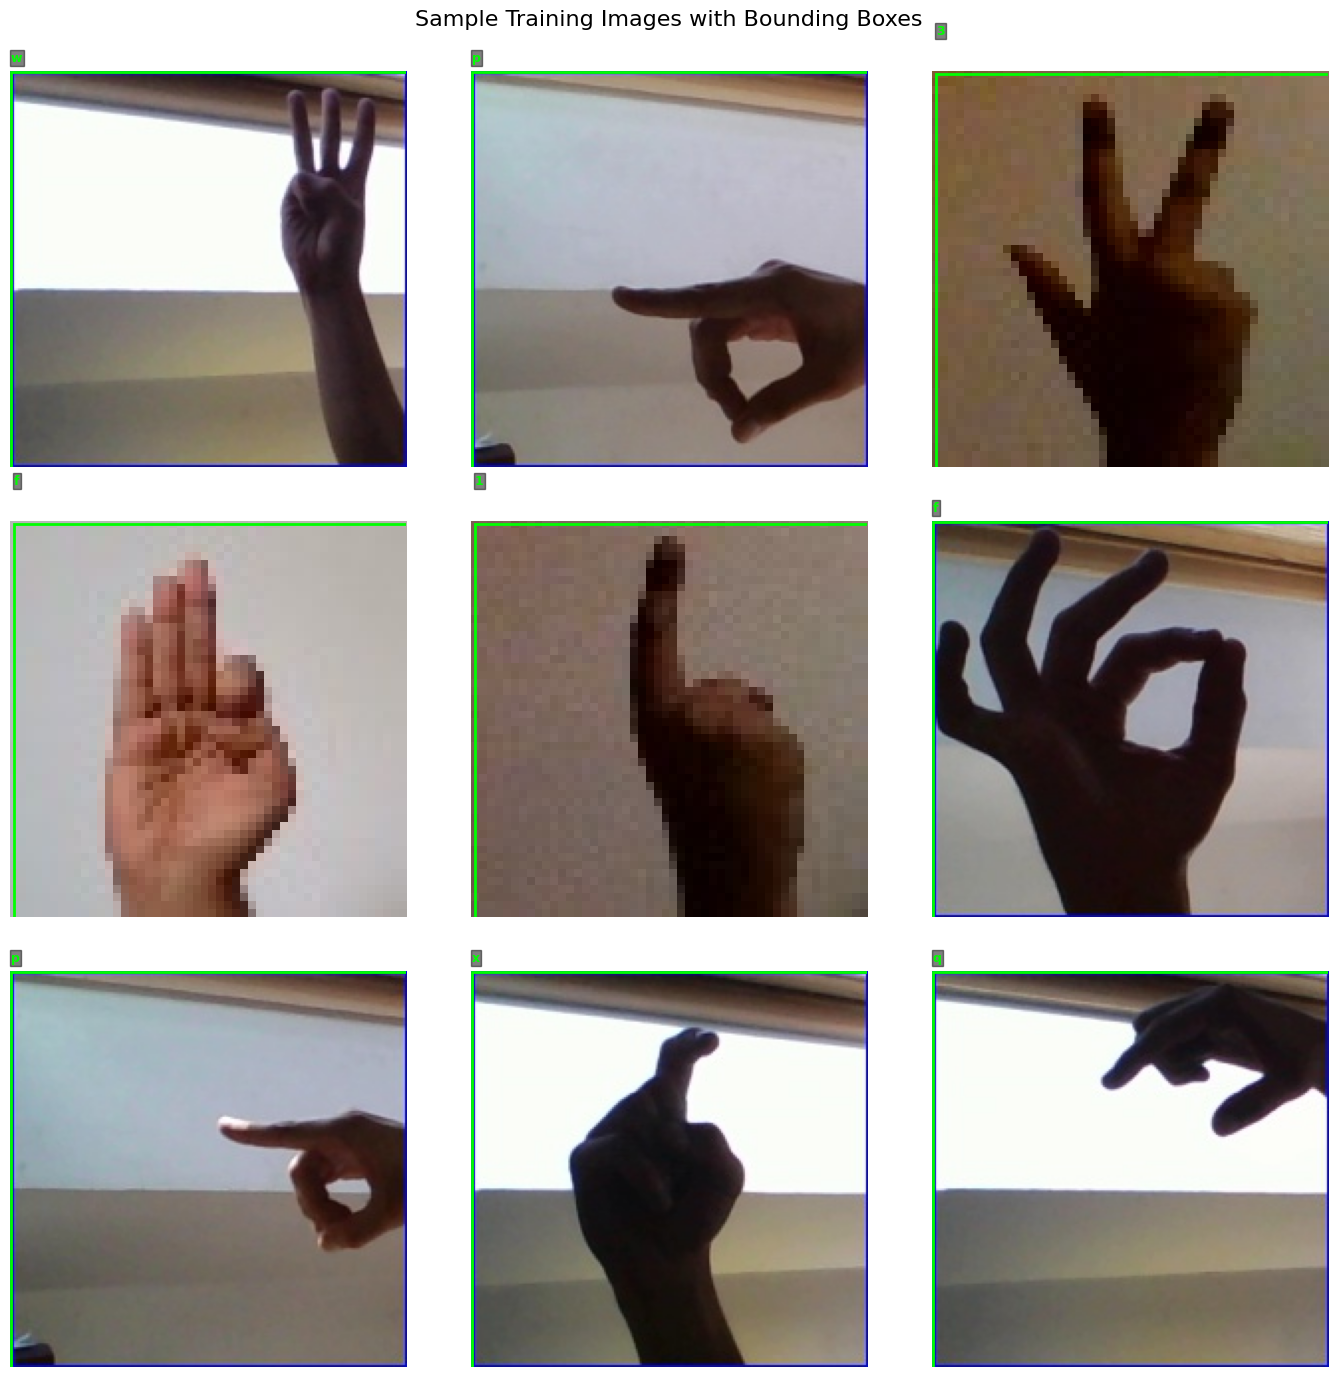

✅ Sample visualization saved!


In [ ]:
# ============================================================
# CELL 12 — Visualize Sample Images with Labels
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

sample_imgs = random.sample(glob.glob(f'{MERGED_DIR}/train/images/*'), min(9, 9))

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle('Sample Training Images with Bounding Boxes', fontsize=16)

for ax, img_path in zip(axes.flatten(), sample_imgs):
    img = Image.open(img_path).convert('RGB')
    W, H = img.size

    lbl_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

    ax.imshow(img)
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                cls_id, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
                x1 = (cx - bw/2) * W
                y1 = (cy - bh/2) * H
                rect = patches.Rectangle((x1, y1), bw*W, bh*H,
                                          linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1 - 5, ALL_CLASSES[cls_id],
                        color='lime', fontsize=9, fontweight='bold',
                        bbox=dict(facecolor='black', alpha=0.5, pad=1))
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_annotations.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Sample visualization saved!")

In [ ]:
# ============================================================
# CELL 13 — Model Setup: YOLO11s (2026 standard)
# YOLO11s is the small variant — fast enough for Colab T4,
# capable enough for 50+ classes.
# ============================================================
from ultralytics import YOLO

# Load YOLO11s pretrained on COCO
model = YOLO('yolo11s.pt')   # Auto-downloads ~18MB weights

print("✅ YOLO11s loaded!")
print(f"   Model parameters: {sum(p.numel() for p in model.model.parameters()):,}")
print(f"   Task: {model.task}")

✅ YOLO11s loaded!
   Model parameters: 9,458,752
   Task: detect


In [ ]:
# ============================================================
# CELL 14 — 🚀 TRAINING
# Estimated time on T4 GPU:
#   50 epochs × ~500 imgs/class × 36 classes ≈ 90-120 minutes
#
# Hyperparameters are tuned for sign language (close-up hand images):
#   - scale=0.3: less scaling needed (hands fill frame)
#   - fliplr=0.0: left-right flip DISABLED (changes sign meaning!)
#   - mosaic=0.5: partial mosaic (helps generalize)
# ============================================================
results = model.train(
    data=DATA_YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,              # GPU 0
    workers=2,
    lr0=0.01,
    lrf=0.01,
    warmup_epochs=3,
    close_mosaic=10,       # Disable mosaic last 10 epochs
    fliplr=0.0,            # ⚠️ CRITICAL: Do NOT flip — signs are direction-sensitive!
    scale=0.3,
    mosaic=0.5,
    patience=15,           # Early stopping if no improvement for 15 epochs
    save=True,
    project='/content/runs',
    name='sign_lang_yolo11s',
    exist_ok=True,
    plots=True,            # Auto-generates training plots
    verbose=True
)

BEST_WEIGHTS = '/content/runs/sign_lang_yolo11s/weights/best.pt'
print(f"\n✅ Training complete! Best weights: {BEST_WEIGHTS}")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/sign_language_dataset/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=sign_lang_yolo11s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [ ]:
# ============================================================
# CELL 15 — 📊 EVALUATION: mAP Metrics on Test Set
# ============================================================
from ultralytics import YOLO

trained_model = YOLO(BEST_WEIGHTS)

print("📊 Running evaluation on TEST set...")
metrics = trained_model.val(
    data=DATA_YAML_PATH,
    split='test',
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    save_json=True,
    project='/content/runs',
    name='sign_lang_eval',
    exist_ok=True
)

print("\n" + "="*60)
print("📈 EVALUATION SUMMARY")
print("="*60)
print(f"  mAP@0.5:      {metrics.box.map50:.4f}  ({metrics.box.map50*100:.1f}%)")
print(f"  mAP@0.5:0.95: {metrics.box.map:.4f}  ({metrics.box.map*100:.1f}%)")
print(f"  Precision:    {metrics.box.mp:.4f}")
print(f"  Recall:       {metrics.box.mr:.4f}")
print("="*60)

In [ ]:
# ============================================================
# CELL 16 — 🗺️ Confusion Matrix Visualization
# ============================================================
from IPython.display import Image as IPImage, display
import os

# YOLO auto-saves confusion matrix during val
cm_path = '/content/runs/sign_lang_eval/confusion_matrix_normalized.png'
if not os.path.exists(cm_path):
    cm_path = '/content/runs/sign_lang_eval/confusion_matrix.png'

if os.path.exists(cm_path):
    print("📊 Confusion Matrix:")
    display(IPImage(cm_path))
else:
    print("⚠️  Confusion matrix file not found. Check /content/runs/sign_lang_eval/")

# Also show training curves
results_path = '/content/runs/sign_lang_yolo11s/results.png'
if os.path.exists(results_path):
    print("\n📈 Training Curves:")
    display(IPImage(results_path))

# Per-class mAP (top 10 and bottom 10)
if hasattr(metrics.box, 'ap_class_index'):
    per_class_ap = list(zip(
        [ALL_CLASSES[i] for i in metrics.box.ap_class_index],
        metrics.box.ap50
    ))
    per_class_ap.sort(key=lambda x: x[1], reverse=True)
    print("\n🏆 Top 10 Classes by AP@0.5:")
    for cls, ap in per_class_ap[:10]:
        print(f"   {cls:<15} {ap:.3f}")
    print("\n⚠️  Bottom 10 Classes by AP@0.5:")
    for cls, ap in per_class_ap[-10:]:
        print(f"   {cls:<15} {ap:.3f}")

In [ ]:
# ============================================================
# CELL 17 — 🎥 PRO-LEVEL WEBCAM INFERENCE (JS ↔ Python Bridge)
#
# This is the production-grade Colab webcam approach:
# 1. JavaScript captures frames from browser webcam
# 2. Frames are sent to Python kernel via eval_js
# 3. YOLO runs inference on each frame
# 4. Bounding boxes are drawn and displayed back in Colab
# ============================================================
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import numpy as np
import cv2
import PIL
import io
from ultralytics import YOLO

trained_model = YOLO(BEST_WEIGHTS)

# ----- Color palette for 50+ classes -----
import colorsys
def generate_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        rgb = colorsys.hsv_to_rgb(hue, 0.85, 0.95)
        colors.append(tuple(int(c * 255) for c in rgb))
    return colors

COLORS = generate_colors(TOTAL_CLASSES)

# ----- JavaScript: Opens webcam, captures frames -----
JS_CODE = """
async function captureFrame() {
  // Request webcam access
  const stream = await navigator.mediaDevices.getUserMedia({video: {width: 640, height: 480}});
  const video = document.createElement('video');
  video.srcObject = stream;
  await new Promise(r => video.onloadedmetadata = r);
  video.play();

  // Create overlay canvas
  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;

  // Display area
  const displayDiv = document.getElementById('webcam-display') ||
                     document.createElement('div');
  displayDiv.id = 'webcam-display';
  document.body.appendChild(displayDiv);
  displayDiv.appendChild(canvas);

  const ctx = canvas.getContext('2d');
  ctx.drawImage(video, 0, 0);

  // Encode frame as JPEG base64
  const data = canvas.toDataURL('image/jpeg', 0.8);
  stream.getTracks().forEach(t => t.stop());
  return data;
}
captureFrame();
"""

def js_to_image(js_reply):
    """Convert JavaScript base64 image to NumPy array."""
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg = PIL.Image.open(io.BytesIO(image_bytes))
    return np.array(jpg)

def bbox_to_bytes(bbox_array):
    """Convert annotated frame to displayable bytes."""
    img_pil = PIL.Image.fromarray(bbox_array)
    iobuf = io.BytesIO()
    img_pil.save(iobuf, format='jpeg', quality=90)
    encoded = b64encode(iobuf.getvalue()).decode('utf-8')
    return encoded

def draw_predictions(frame, results):
    """Draw YOLO bounding boxes on frame."""
    annotated = frame.copy()
    H, W = annotated.shape[:2]

    if results[0].boxes is not None:
        for box in results[0].boxes:
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            color = COLORS[cls_id % len(COLORS)]
            label = f"{ALL_CLASSES[cls_id]} {conf:.0%}"

            # Draw box
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 3)

            # Label background
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)
            cv2.rectangle(annotated, (x1, y1-th-10), (x1+tw+6, y1), color, -1)

            # Label text
            cv2.putText(annotated, label, (x1+3, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2, cv2.LINE_AA)

    # Overlay: class count
    cv2.putText(annotated, f"YOLO11s | {TOTAL_CLASSES} classes",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
    return annotated

print("✅ Webcam inference functions loaded!")
print("   Run the next cell to start real-time detection.")

In [ ]:
# ============================================================
# CELL 18 — 🎥 RUN LIVE WEBCAM INFERENCE
# Run this cell repeatedly to capture and infer on frames.
# Each run: captures 1 frame → runs YOLO → displays result.
# For continuous mode, set CONTINUOUS_FRAMES > 1
# ============================================================
from IPython.display import display as ipy_display, Image as IPImage
import time

CONTINUOUS_FRAMES = 10   # Number of frames to process per run
CONF_THRESHOLD = 0.35    # Minimum confidence to show detection

print(f"🎥 Starting webcam inference ({CONTINUOUS_FRAMES} frames)...")
print("   📌 Allow camera access when browser asks!")

for frame_num in range(CONTINUOUS_FRAMES):
    try:
        # Capture frame via JS
        js_reply = eval_js(JS_CODE)
        frame = js_to_image(js_reply)

        # YOLO inference
        results = trained_model.predict(
            source=frame,
            conf=CONF_THRESHOLD,
            iou=0.4,
            imgsz=640,
            device=0,
            verbose=False
        )

        # Draw bboxes
        annotated = draw_predictions(frame, results)

        # Display in Colab
        encoded = bbox_to_bytes(annotated)

        # Show detected classes
        detected = []
        if results[0].boxes is not None:
            for box in results[0].boxes:
                cls_id = int(box.cls[0])
                conf   = float(box.conf[0])
                detected.append(f"{ALL_CLASSES[cls_id]}({conf:.0%})")

        print(f"Frame {frame_num+1:02d}/{CONTINUOUS_FRAMES} | "
              f"Detected: {', '.join(detected) if detected else 'nothing'}")

        display(Javascript(f"""
          var img = document.createElement('img');
          img.src = 'data:image/jpeg;base64,{encoded}';
          img.style.maxWidth = '100%';
          var div = document.getElementById('output-{frame_num}') || document.createElement('div');
          div.id = 'output-{frame_num}';
          div.innerHTML = '';
          div.appendChild(img);
          element.appendChild(div);
        """))

        time.sleep(0.1)  # Small delay between frames

    except Exception as e:
        print(f"⚠️  Frame {frame_num+1} error: {e}")
        print("   If this is a JS error, reload the page and re-run Cell 2.")
        break

print("\n✅ Webcam inference session complete!")

In [ ]:
# ============================================================
# CELL 19 — 💾 Export & Download Best Model
# ============================================================
from google.colab import files
import shutil

# Export to ONNX for portability (optional)
print("📦 Exporting model to ONNX format...")
trained_model.export(format='onnx', imgsz=640, dynamic=True)

# Zip up results
print("📦 Zipping results for download...")
shutil.make_archive('/content/sign_lang_results', 'zip', '/content/runs')

# Download best weights
print("⬇️  Downloading best.pt weights...")
files.download(BEST_WEIGHTS)

# Download full results zip
print("⬇️  Downloading results zip (confusion matrix, plots, metrics)...")
files.download('/content/sign_lang_results.zip')

print("\n✅ All done! Your lab deliverables are downloaded.")
print("\n📋 Deliverables Summary:")
print("   • best.pt          — YOLO11s fine-tuned weights (50+ classes)")
print("   • sign_lang_results.zip — Training curves, confusion matrix, mAP")
print("   • data.yaml        — Dataset config with all class names")

---
## 🧠 Troubleshooting Guide

| Problem | Fix |
|---------|-----|
| `kaggle: command not found` | Re-run Cell 2 completely |
| `404` on Roboflow download | Your API key may be invalid — regenerate at app.roboflow.com |
| `CUDA out of memory` | Reduce `batch=16` to `batch=8` in Cell 14 |
| Webcam not opening | Browser must allow camera. Use Chrome. Reload page. |
| Low mAP (<0.4) | Increase `MAX_IMAGES_PER_CLASS` to 1000, or run 100 epochs |
| `FileNotFoundError: data.yaml` | Re-run Cell 10 after Cells 8-9 succeed |
| Labels out of range in Cell 11 | Roboflow dataset class count mismatch — re-check `rf_classes` in Cell 8 |

## 📚 Academic References
- Arikeri, P. *American Sign Language (ASL) Dataset.* Kaggle, 2023.
- Roboflow Universe. *Sign Language Detection YOLOv10 Dataset.* 2024.
- Ultralytics. *YOLO11: Real-time Object Detection.* 2024.
- MDPI (2025). *AI-Powered Sign Language Detection Using YOLO-v11.*
